Created 10/9/25 to back up a working version of sandbox2.ipynb before I change how the sector and time handling is done.

Outline
- Imports, set up, and helper functions
- Define observing strategies
- Define parameter ranges for per, tc, etc
- Run on the main mission
- Run on the extended mission strategies
- Save outputs
- Analysis

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from astropy.time import Time
from more_itertools import consecutive_groups
import warnings

from tess_stars2px import TESS_Spacecraft_Pointing_Data
from tess_stars2px import tess_stars2px_function_entry as tess_stars2px


## Set Up

In [2]:
# Read csvs
df = pd.read_csv('./target_df_longform.csv')
tdf = pd.read_csv('./target_df_shortform.csv')
df = df.drop(columns=df.columns[0])
tdf = tdf.drop(columns=tdf.columns[0])

# also fix the sec columns to that it isn't a string for some reason
from ast import literal_eval    
tdf["sec"] = tdf["sec"].apply(lambda x: literal_eval(x))

# ingest positions catalog
cat = pd.read_csv('CTLv8 (current).csv')
cat.rename(columns={'Right_Ascension':'ra', 'Declination':'dec', "TESSmag":'Tmag', 'Ecliptic_Longitude':'ec_long', 'Ecliptic_Latitude':'ec_lat', 'TIC_ID':'TIC'}, inplace=True)
# cat[:5]

# get the list of all unique sector combinations
# at some point, I'll need to match these up with the positions catalog so we can translate between them easily
sec_unique =  np.array([np.array(x) for x in set(tuple(x) for x in tdf.sec.values)])
print(len(sec_unique))


1800


/var/folders/kk/_9cq7r5j5nd8cxryt5p59v2c0000gn/T/ipykernel_1436/703560004.py:18: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  sec_unique =  np.array([np.array(x) for x in set(tuple(x) for x in tdf.sec.values)])


In [3]:
# extract scheduling info
scinfo = TESS_Spacecraft_Pointing_Data(1)

# Note: Midtimes really do seem to be the MIDDLE of the tess sector, so inclusive times for it will be +/- 13.5 days
# goes up to sector 96, which is the conclusion of Year 7 observing (mix of north/south + some ecliptic)
midtimes = np.array(TESS_Spacecraft_Pointing_Data.midtimes)
sec_cadence = np.mean(midtimes[1:] - midtimes[:-1]) # average time between sector midtimes
midtimes_fake = np.arange(len(midtimes)) * sec_cadence + midtimes[0]

sectors_all = TESS_Spacecraft_Pointing_Data.sectors
missionStart = midtimes[0] - 13.5
missionStop = midtimes[-1] + 13.5

# arrays that have the start and stop times of each sector
start_times = midtimes - 13.5
stop_times = midtimes + 13.5


In [49]:
missionStart

2458326.152778

In [ ]:
orbit_times.iloc[0].Sector

1

In [115]:
# additional scheduling info from new data tables
# orbit_times = pd.read_csv('Table_of_momentum_dumps.csv', skiprows=[0,1,2,3,5,6])#header=4)
orbit_times = pd.read_csv('TESS_orbit_times.csv')[:-1]

# t = orbit_times.iloc[0]['Start of Orbit']
# print(Time(t).jd)
# print(missionStart)
# print(max(orbit_times.Sector.values))

# reformat
orbit_times.rename(columns={'Sector':'sector', 'Orbit':'orbit'}, inplace=True)
orbit_times['sector'] = orbit_times['sector'].astype(int)

# convert the start and stop times to JD
orbit_times['t_start'] = [Time(orbit_times['Start of Orbit'].values[i]).jd for i in range(len(orbit_times))]
orbit_times['t_end'] = [Time(orbit_times['End of Orbit'].values[i]).jd for i in range(len(orbit_times))]

# add in the midtransit times for all sectors
orbit_times['midtime'] = 0.
for index, row in orbit_times.iterrows():
    sec = row.sector
    orbit_times.at[index, 'midtime'] = midtimes[sec-1]

orbit_times[-10:]

,sector,orbit,Start of Orbit,End of Orbit,t_start,t_end,midtime
274,97,201.0,2025-09-15 03:50:00,2025-09-22 05:25:00,2.460934e+06,2.460941e+06,2460961.0
275,97,201.0,2025-09-22 10:25:00,2025-09-28 08:55:00,2.460941e+06,2.460947e+06,2460961.0
276,97,202.0,2025-09-28 13:55:00,2025-10-05 14:00:00,2.460947e+06,2.460954e+06,2460961.0
277,97,202.0,2025-10-05 19:00:00,2025-10-12 01:10:00,2.460954e+06,2.460961e+06,2460961.0
278,98,203.0,2025-10-12 06:10:00,2025-10-18 23:55:00,2.460961e+06,2.460967e+06,2461017.0
279,98,203.0,2025-10-19 03:45:00,2025-10-26 06:15:00,2.460968e+06,2.460975e+06,2461017.0
280,98,204.0,2025-10-26 11:15:00,2025-11-02 07:40:00,2.460975e+06,2.460982e+06,2461017.0
281,98,204.0,2025-11-02 12:40:00,2025-11-08 19:00:00,2.460982e+06,2.460988e+06,2461017.0
282,99,205.0,2025-11-09 00:00:00,2025-11-16 10:00:00,2.460988e+06,2.460996e+06,2461059.5
283,99,205.0,2025-11-16 15:00:00,2025-11-23 07:15:00,2.460996e+06,2.461003e+06,2461059.5


At some point I need to figure out how to add additional sectors to this, but that's a later problem.

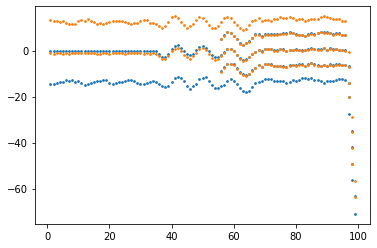

In [ ]:
# plt.errorbar(np.ones_like(len(orbit_times)), y, yerr=y_error_asym, fmt='o', capsize=5, ecolor='blue')

# plt.scatter(orbit_times.sector, orbit_times.midtime, s=3)
plt.scatter(orbit_times.sector, orbit_times.t_start - orbit_times.midtime, s=3)
plt.scatter(orbit_times.sector, orbit_times.t_end - orbit_times.midtime, s=3)



In [7]:
TESS_Spacecraft_Pointing_Data.sectors

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121])

In [615]:
scinfo.__dict__.keys()


dict_keys(['sectors', 'ras', 'decs', 'rolls', 'midtimes', 'camRa', 'camDec', 'fpgObjs'])

## Functions

In [8]:
# make a class that makes it easier to store information on an observing strategy
# in the future, might add something to indicate that something is part of a "curent" or "future" mission
# maybe also add a plotting function so you can visualize your strategy

class ObservingStrategy:
    def __init__(self, sectors, ras, decs, rolls, midtimes, extended_mission=None):
        self.sectors = sectors
        self.ras = ras
        self.decs = decs
        self.rolls = rolls
        self.midtimes = midtimes

        # provenance tracks which of the original TESS sectors the pointing info for this sector comes from
        self.provenance = sectors

        # boolean to keep track of whether the sectors should be considered part of the "base" mission or a future "extended" mission
        if extended_mission is None:
            self.extended_mission = [False] * len(self.sectors)
        else:
            self.extended_mission = extended_mission
        pass

    def add_sector(self, provenance, new_sectors=True):
        """Adds new sectors to the observing strategy"""
        ...

    def check_observability(self, base_strat_sectors):
        """Compares the observability in the base strategy (i.e. the default TESS mission from sectors 1-96) and returns the sectors in which a star would be observed in this strategy."""
        ...

In [9]:
# Helper Functions
def max_consecutive_sequence(arr):
    return max([len(list(i)) for i in consecutive_groups(arr)])


In [10]:
def calc_transit_times_phase(period, tc_phase, dur=2, start_time=missionStart, stop_time=missionStop):
    """period - days
    tc_phase - int or arr, the fractional phase that the transit occurs at
    duration - duration in hours

    Return - matrix, each row associated with a different tc_phase
    """
    tc_phase = np.atleast_1d(tc_phase)
    transit_times = [np.arange(start_time + phase*period, stop_time, period) for phase in tc_phase]
    return np.array(transit_times)

def calc_transit_times_tc(period, tc, dur=2, start_time=missionStart, stop_time=missionStop):
    """period - days
    tc - one time that the transit occurs at (does not need to be the first)
    duration - duration in hours
    """
    tc = np.atleast_1d(tc)

   # Calculate the first occurrence of the event time after the start time
    first_occurences = [start_time + ((t - start_time) % period) for t in tc]
    transit_times = [np.arange(fo, stop_time + 1, period) for fo in first_occurences]
    return np.array(transit_times)

def check_observability(transit_times, sectors):
    """
    Given a list of transit times (can be 2D) and sector numbers, returns a boolean matrix saying whether each transit event would be observed. 
    
    Output: 
        trans_obs - boolean matrix for transit observability (n_tc, n_transits)
        sec_obs - boolean matrix whether or not a sector captured a transti (n_tc, n_sec)
    """
    # get the index of the sectors
    sec_ind = sectors - 1
    
    # check if each transit event falls within an observed sector
    mat = (np.abs(transit_times[:,:,None] - midtimes[sec_ind][None,None,:]) < 13.5) & (np.abs(transit_times[:,:,None] - midtimes[sec_ind][None,None,:]) > 0.3) 
    
    # summing over different axes gives you different statistics
    trans_obs = np.sum(mat, axis=2)  # obs bool for each transit event
    sec_obs = np.sum(mat, axis=1)  # obs bool for each sector event
    return trans_obs, sec_obs

In [11]:
def find_all_aliases(transit_times, sectors, trans_obs, sec_obs, min_period=13):
    """
    Finds all aliases between the minimum and maximum possible period.

    Returns:
        n_a - arr, the alias number (starting from 1)
        aliases - the period of each alias
    """
    if np.sum(trans_obs) == 1:
        # print("Mono-transit")
        return [], []
    elif np.sum(trans_obs) == 0:
        # print("No transits detected")
        return [], []
    
    # longest baseline of consecutive sectors
    baseline = max_consecutive_sequence(sectors) * sec_cadence / 2

    # the maximum possible period is the difference between the two most closely spaced observed transits
    data = transit_times[trans_obs]
    max_alias = np.min(np.abs(data[1:] - data[:-1]))
    min_alias = max(min_period, baseline) 

    # don't let the minimum alias number go below zero
    min_n = np.floor(max_alias / min_alias)
    if min_n == 0:
        min_n = 1

    print(min_alias)

    # generate return arrays
    n_a = np.arange(1, min_n+1).astype(int) # alias number  
    aliases = max_alias / n_a               # alias period value
    return n_a, aliases

def rule_out_aliases(transit_times, sector_times, trans_ob, sec_ob, a_periods):
        # a_periods, event_time, secondary_times):
    """For a list of alias a_periods, returns True if that period would result in a transit taking place during ANY sector specified by the secondary_times.
    
    Inputs:
        a_periods - a float or list of possible a_periods
        event_time - a time at which a transit was observed
        secondary_times - the midpoints of sectors in which transits were NOT observed
    
    Returns: arr[bool] where True means that that alias can be ruled out.
    """
    # extract useful variables
    a_periods = np.atleast_1d(a_periods)
    observed_transits = transit_times[trans_ob]

    # Initialize result array with False values
    ruled_out = [False] * len(a_periods)  
    
    for i, period in enumerate(a_periods):
        # check that no transits would occur in sectors with no transit detection
        for secondary_time in sector_times[~sec_ob]:
            time_diff = (secondary_time - observed_transits[0]) % period
            time_diff = min(time_diff, period - time_diff)
            if (time_diff < 13.5) & (time_diff > 0.3) :
                ruled_out[i] = True 
                break  # No need to continue checking for this period
            
        # no need to keep checking if we've already ruled this alias out
        if ruled_out[i] == True:
            continue

        # check that this alias produces a transit when real transits are observed
        alias_transits = calc_transit_times_tc(period, observed_transits[0])[0]
        if not set(np.round(observed_transits,1)).issubset(set(np.round(alias_transits, 1))):
            ruled_out[i] = True
            continue

    return np.array(ruled_out)

# ruled_out = rule_out_aliases(transit_times, sector_times, trans_ob, sec_ob, a_per)

def analyze_aliases_and_flag(transit_times, sectors, sector_times, trans_ob, sec_ob):
    """    
    0 - No transits observed
    1 - Mono-transit
    2 - Duo+ transit, but unresolve aliases remaining
    3 - Solved
    """
    # default values
    n_a, aliases, ruled_out = [], [], []
    flag = -1

    num_transits_observed = len(transit_times[trans_ob])
    # sector_times = midtimes_fake[sectors-1]

    if np.sum(trans_ob) > np.sum(sec_ob):
        # if multiple transits were caught in a single sector, then the period is solved
        # print('Sovled!')
        flag = 3
    elif num_transits_observed == 0:
        # print("No transits captured")
        # plot_transits()
        flag = 0
    elif num_transits_observed == 1:
        # print("Mono-transit")
        # plot_transits()
        flag = 1
    else:
        first_observed_transit = transit_times[trans_ob][0]
        n_a, a_periods = find_all_aliases(transit_times, sectors, trans_ob, sec_ob)
        # see what is ruled out by the empty sectors
        # ruled_out = rule_out_aliases(a_periods, first_observed_transit, sector_times[~sec_ob])
        ruled_out = rule_out_aliases(transit_times, sector_times, trans_ob, sec_ob, a_periods)

        # print the status
        if len(a_periods[~ruled_out]) > 1 :
            # print("Still ambiguous!")
            flag = 2
        elif len(a_periods[~ruled_out]) == 1 :
            # print('Sovled!')
            flag = 3
        else:
            print("Something went wrong")
        # plot_aliases()
    
    return flag, n_a, a_periods, ruled_out


In [16]:
flag, n_a, a_per, ruled_out = analyze_aliases_and_flag(transit_times, sectors, sector_times, trans_ob, sec_ob)

a_per, ruled_out

41.42934027499869


(array([675.        , 337.5       , 225.        , 168.75      ,
        135.        , 112.5       ,  96.42857143,  84.375     ,
         75.        ,  67.5       ,  61.36363636,  56.25      ,
         51.92307692,  48.21428571,  45.        ,  42.1875    ]),
 array([ True,  True,  True,  True, False,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True]))

In [576]:
print(n_a[40])
print(a_per[40])

for x in sector_times[~sec_ob]:
    time_diff = (x - transit_times[trans_ob][0]) % a_per[40]
    time_diff = min(time_diff, a_per[40]-time_diff)
    print(time_diff)

# print(transit_times[trans_ob][0])
transit_times[trans_ob]

41
36.21951219512195
16.072916999924928
4.550170902730656
13.493080097614069
1.4332658049831934


array([2459284.652778, 2460769.652778])

In [521]:
arr1 = [.09, .123, .3425]
arr1 = np.round(arr1, 1)
arr2 = [.1, .29, .8]
print(set(np.round(arr2, 1)))

set(np.round(arr1, 1)).issubset(set(np.round(arr2, 1)))


{0.1, 0.8, 0.3}


True

Notes:
 - Need to adapt analyze_aliases_and_flag()
 - Need to organize how to store outputs
 - add plotting functions back in
 - add monotransits back in
 
Need to add ability to add additional sectors of observation and figure out if it rules out more aliases or not. Do I want to do this by adding additional information to what I've already calculated, or by rerunning the whole thing anew?

Look into parallelism to see if I can run this thing faster.


array([False, False, False])

## Dev

In [14]:
# Get the workflow figured out
period = 135
tc_phase = [0.1, 0.2]
# sectors = sec_unique[1]
# sec_ind = sec_unique[1]-1

# calculate the transit times
# shape: (n_ph, n_transits)
all_transit_times = calc_transit_times_phase(period, tc_phase)
# transit_times = calc_transit_times_phase(period, 0.1)

# check observability of each transit
# trans_obs, sec_obs = check_observability(all_transit_times, sectors)

# # if you want to do a bunch of sector arrangements at once, you can do this (takes less than a second)
# shape: (n_sec, n_ph, n_transits)
temp = [check_observability(all_transit_times, sec_unique[i]) for i in range(len(sec_unique))]
all_trans_obs, all_sec_obs = [list(a) for a in zip(*temp)]  

# np.shape(transit_times)
# np.shape(start_times)
# print(trans_obs.shape, sec_obs.shape)



In [17]:
# after this point, I think we need to start treating each case individually
n_s = 718   # index for combination of sectors
n_ph = 1  # index for tc_phase
# n_p = 0  # index for period, add later

# unpack values for readability, all these will be 1d
transit_times = all_transit_times[n_ph]
sectors = sec_unique[n_s]

trans_ob = (all_trans_obs[n_s][n_ph]).astype(bool)
sec_ob = (all_sec_obs[n_s][n_ph]).astype(bool)
observed_transit_times = transit_times[trans_ob]
sector_times = midtimes[sec_unique[n_s]-1]

# print(transit_times[trans_ob])

# find all possible aliases
n_a, a_per = find_all_aliases(transit_times, sectors, trans_ob, sec_ob, min_period=13)

# eliminate the ones which are impossible
empty_sectors = sector_times[~sec_ob]
first_observed_transit = observed_transit_times[0]
# ruled_out = rule_out_aliases(a_per, first_observed_transit, empty_sectors)
ruled_out = rule_out_aliases(transit_times, sector_times, trans_ob, sec_ob, a_per)

flag, n_a, a_per, ruled_out = analyze_aliases_and_flag(transit_times, sectors, sector_times, trans_ob, sec_ob)

a_per, ruled_out


# flag, n_a, aliases, ruled_out = analyze_aliases_and_flag(transit_times, sec, trans_ob, sec_ob)

41.42934027499869
41.42934027499869


(array([675.        , 337.5       , 225.        , 168.75      ,
        135.        , 112.5       ,  96.42857143,  84.375     ,
         75.        ,  67.5       ,  61.36363636,  56.25      ,
         51.92307692,  48.21428571,  45.        ,  42.1875    ]),
 array([ True,  True,  True,  True, False,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True]))

The next step is to make it possible to rule out additional aliases by adding an additional sector of observation. Since future sectors might be of different lengths, we're going to require inputting a start time and a stop time in, instead of just a midtime.

In [ ]:
def check_new_sector(period, tc, flag, n_a, a_per, ruled_out, ti, tf, obs_bool):
    """
    Given a new period of observation, checks whether a correct transit will be observed during it and rules out additional aliases based on the new data.

    ti - start time of new period of observation
    tf - end time of new period of observation
    obs_bool - whether or not the transit is observed in this sector
    """
    if flag == -1:
        warnings.warn("Flag==1. System has not be evaluated for aliases.")
        return
    if flag == 1:
        


# flag, n_a, a_per, ruled_out


calc_transit_times_tc(period, tc, dur=2, start_time=ti, stop_time=tf):

In [23]:
TESS_Spacecraft_Pointing_Data.__dict__.keys()

dict_keys(['__module__', 'sectors', 'ras', 'decs', 'rolls', 'midtimes', 'camSeps', '__init__', '__dict__', '__weakref__', '__doc__'])

In [29]:
(-40.5 + -56. + -42.5) / 27.5

-5.054545454545455

In [20]:
# plt.plot(TESS_Spacecraft_Pointing_Data.midtimes)
TESS_Spacecraft_Pointing_Data.midtimes[:-1] - TESS_Spacecraft_Pointing_Data.midtimes[1:]

array([-28.940972, -28.065972, -27.888889, -27.      , -26.555556,
       -26.59375 , -25.559027, -26.465278, -26.038195, -28.013889,
       -29.256944, -28.586806, -28.71875 , -27.597222, -26.715278,
       -26.072916, -25.71875 , -25.517361, -27.430556, -28.527778,
       -28.649305, -28.263889, -27.434028, -27.645833, -26.197917,
       -26.038194, -26.020834, -27.152777, -27.881945, -28.652778,
       -28.086805, -28.486111, -26.552084, -26.600694, -26.721316,
       -27.276603, -27.276602, -27.276603, -27.276603, -27.276603,
       -27.276603, -27.276603, -27.276603, -27.276602, -27.276603,
       -27.276603, -27.276603, -27.276603, -27.276603, -27.276602,
       -27.276603, -27.276603, -27.276603, -27.276603, -27.276603,
       -27.276603, -27.276602, -27.276603, -27.276603, -27.276603,
       -27.276603, -27.276603, -27.276603, -27.276602, -27.276603,
       -27.276603, -27.276603, -27.276603, -25.070929, -26.      ,
       -26.      , -26.5     , -27.      , -27.      , -28.   

Text(0.5, 0, 'JD')

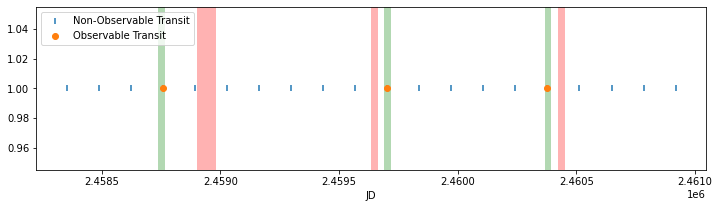

In [622]:
# plot transits and sectors
fig, ax = plt.subplots(figsize=[12,3])
for ind in range(len(sector_times)):
    st = sector_times[ind]
    if ~sec_ob[ind]:
        plt.axvspan(st-13.5, st+13.5, alpha=0.3, color='red', linestyle='')
    else:
        plt.axvspan(st-13.5, st+13.5, alpha=0.3, color='green', linestyle='')
ax.scatter(transit_times, np.ones_like(transit_times), marker='|', label='Non-Observable Transit')
ax.scatter(transit_times[trans_ob], np.ones_like(transit_times[trans_ob]), label='Observable Transit')
ax.legend()
ax.set_xlabel('JD')


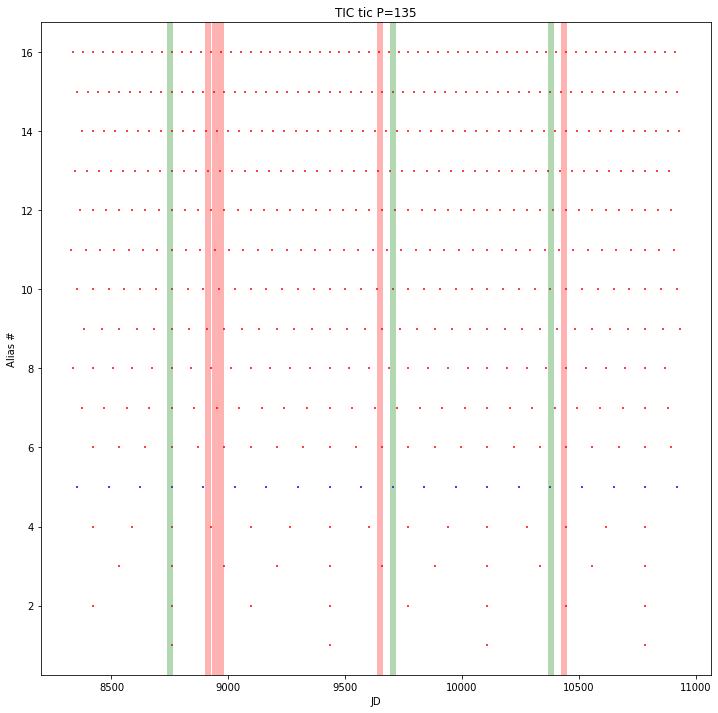

In [607]:
plt.figure(figsize=[12,12])
for ind in range(len(a_per)):
    transits = calc_transit_times_tc(a_per[ind], first_observed_transit)
    if ruled_out[ind]:
        plt.scatter(transits-2450000, np.ones_like(transits)*n_a[ind], marker='|', s=3, c='red')
    else:
        plt.scatter(transits-2450000, np.ones_like(transits)*n_a[ind], marker='|', s=3, c='blue')

for ind in range(len(sector_times)):
    st = sector_times[ind]
    if ~sec_ob[ind]:
        plt.axvspan(st-13.5-2450000, st+13.5-2450000, alpha=0.3, color='red', linestyle='')
    else:
        plt.axvspan(st-13.5-2450000, st+13.5-2450000, alpha=0.3, color='green', linestyle='')

plt.xlabel('JD')
plt.ylabel('Alias #')  
plt.title('TIC ' + str('tic') + ' P=' + str(round(period, 2)))  
plt.show()

In [ ]:
all_gaps = [np.abs(x1-x2) for x1 in observed_transit_times for x2 in observed_transit_times]
all_gaps = set(all_gaps) - {0}
all_gaps

{405.0, 540.0, 675.0, 945.0, 1080.0, 1620.0}

In [ ]:
transit_times[trans_ob] - 2458700

[  44.65,  719.65, 1124.65, 1664.65]

[44.652778, 720.152778, 1125.652778, 1666.152778]

In [ ]:
print(period)
print(transit_times[trans_ob][1:] - transit_times[trans_ob][:-1])
print(a_per)
# transit_times[trans_ob] - 2458000

gaps = transit_times[trans_ob][1:] - transit_times[trans_ob][:-1]
np.abs(gaps[1:] - gaps[:-1]) 

k=0
alias_events = calc_transit_times_tc(a_per[k], first_observed_transit)


135
[675. 405. 540.]
[405.         202.5        135.         101.25        81.
  67.5         57.85714286  50.625       45.        ]


array([[2458339.652778, 2458744.652778, 2459149.652778, 2459554.652778,
        2459959.652778, 2460364.652778, 2460769.652778]])

In [ ]:
empty_sector_times = midtimes[sec_unique[n_s]][(all_sec_obs[n_s][n_ph]).astype(bool)]
first_observed_transit = transit_times[n_ph][(all_trans_obs[n_s][n_ph]).astype(bool)][0]



(array([], dtype=float64), array([], dtype=float64))

In [158]:
print(transit_times[0] - start_time)
print(midtimes[sec_ind] - start_time)

[  13.5  148.5  283.5  418.5  553.5  688.5  823.5  958.5 1093.5 1228.5
 1363.5 1498.5 1633.5 1768.5 1903.5 2038.5 2173.5 2308.5 2443.5 2578.5]
[ 371.184028  398.78125   425.496528 1105.531413 1460.12725  1487.403853
 1514.680456 2026.847222 2054.847222 2193.347222 2219.347222 2245.347222]


## Define Observing Strats

In [11]:
# Helper Functions
def extend_sectors(sectors, ext_strategy):
    """sectors - the sectors observed from 1-96
    ext_strategy - the sectors who's pointings will be repeated in the extended mission, in order of execution"""
    sec_set = set(sectors)
    full_strategy = np.hstack([np.arange(1,97), ext_strategy])
    full_secs = np.array([i+1 for i, val in enumerate(full_strategy) if val in sec_set])

    return full_secs

def get_new_midtimes(full_secs, midtimes_ext):
    return(midtimes_ext[np.array(full_secs)-1])

def add_new_observations(period, tc, new_midtimes, aliases, ruled_out):
    # check if a transit will appear in the new sectors
    true_obs = check_event_within_period(period, tc, new_midtimes)

    # check if the aliases would appear in the new sectors
    newly_ruled_out = np.array([True] * len(aliases))
    for ind in range(len(aliases)):
        if ~ruled_out[ind]:
            # see if that alias would result in a transit in the new sector
            pred_obs = check_event_within_period(aliases[ind], tc, new_midtimes)
            # print(pred_obs)

            # if any of the observations do not match the prediction, then that alias can be ruled out
            newly_ruled_out[ind] = (true_obs!=pred_obs)

    return np.array(newly_ruled_out).astype(bool)
   

In [12]:
# Define Strategies
# Assume that the extended mission will reuse pointings from previous sectors

# Default strategy, go south -> north
def_strat = sectors_all[:26]

# Flipped strategy, go north -> south
flip_strat = np.hstack([sectors_all[13:26], sectors_all[:13]])

(0.0, 120.0)

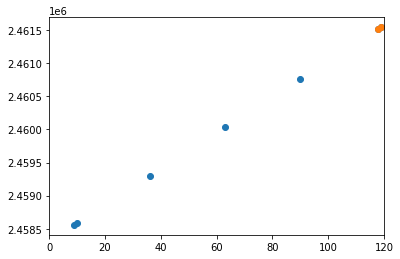

In [14]:
# example usage
# strat = def_strat
strat = flip_strat

# midtimes of just the extended mission
strat_midtimes = midtimes[-1] + sec_cadence * (1 + np.arange(len(strat)))

# "real" sector numbers and midtimes for the full mission (base+extended)
sectors_ext = np.arange(1, len(sectors_all)+len(strat)+1)
midtimes_ext = np.hstack([midtimes, strat_midtimes])

# extended mission start and stop
extStart = midtimes_ext[0] - sec_cadence
extStop = midtimes_ext[-1] + sec_cadence

# for a specific star
s = np.asarray(tdf.loc[301, 'sec'])
full_secs = extend_sectors(s, strat)  # target sectors, strategy
full_midtimes = get_new_midtimes(full_secs, midtimes_ext)
new_secs = full_secs[full_secs>96]
new_midtimes = full_midtimes[full_midtimes>missionStop]
# new_midtimes

plt.scatter(full_secs, full_midtimes)
plt.scatter(new_secs, new_midtimes)
plt.xlim([0,120])

## Run Experiment

In [ ]:
# define your range of periods and tc_phases]
periods = np.arange(20,70,.8)
tc_phases = np.arange(0,1,.1)

rows_list = []


In [ ]:
# Define target matrix
# copy in what I did with Mallory here


8156
1800


## Analyze Results

In [8]:
# calc_transit_times_phase(51.45, .1)

# let's make calc_transit_times able to take in arrays of periods and tcs

start_time = 0

periods = np.array([10,12,15])
# tc_phases = np.array([0,.1,.2])


np.arange(start_time + tc_phase*period, stop_time, period)


array([2458331.297778  , 2458382.747778  , 2458434.197778  ,
       2458485.647778  , 2458537.097778  , 2458588.547778  ,
       2458639.997778  , 2458691.447778  , 2458742.897778  ,
       2458794.347778  , 2458845.797778  , 2458897.247778  ,
       2458948.697778  , 2459000.147778  , 2459051.597778  ,
       2459103.047778  , 2459154.497778  , 2459205.947778  ,
       2459257.397778  , 2459308.847778  , 2459360.297778  ,
       2459411.747778  , 2459463.197778  , 2459514.647778  ,
       2459566.097778  , 2459617.547778  , 2459668.997778  ,
       2459720.44777801, 2459771.89777801, 2459823.34777801,
       2459874.79777801, 2459926.24777801, 2459977.69777801,
       2460029.14777801, 2460080.59777801, 2460132.04777801,
       2460183.49777801, 2460234.94777801, 2460286.39777801,
       2460337.84777801, 2460389.29777801, 2460440.74777801,
       2460492.19777801, 2460543.64777801, 2460595.09777801,
       2460646.54777801, 2460697.99777801, 2460749.44777801,
       2460800.89777801,